# 30-Day Hospital Readmission Prediction

End-to-end analysis: cleaning, feature engineering, model comparison,
interpretation, calibration, and a fairness audit.

Dataset: UCI Diabetes 130-US Hospitals (101,766 encounters, 1999-2008).

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import shap
from pathlib import Path
from sklearn.model_selection import (
    cross_val_predict, StratifiedKFold, StratifiedGroupKFold, train_test_split
)
from sklearn.calibration import calibration_curve
from sklearn.metrics import roc_auc_score, average_precision_score

from src.load_data import load_raw
from src.clean import clean, TARGET, DEATH_HOSPICE_IDS
from src.icd9 import add_diagnosis_groups
from src.features import prepare, add_engineered_features, split_xy
from src.models import (
    lightgbm_native, to_category_dtype, logistic_baseline, LGBM_BEST_PARAMS
)
from src.mlp import train_mlp
from src.evaluate import evaluate, precision_at_k

pd.set_option("display.width", 120)

## 1. Exploratory analysis

Four questions that determine the modelling design.

In [2]:
raw = load_raw()
print("shape:", raw.shape)

counts = raw.patient_nbr.value_counts()
print(f"\nunique patients: {raw.patient_nbr.nunique()} of {len(raw)} rows")
print(f"max encounters for one patient: {counts.max()}")
print(f"share of rows that are repeat encounters: "
      f"{(len(raw) - raw.patient_nbr.nunique()) / len(raw):.4f}")

print("\ntarget distribution:")
print(raw.readmitted.value_counts())
print(f"\n30-day positive rate: {(raw.readmitted == '<30').mean():.4f}")
print(f"late (>30) share: {(raw.readmitted == '>30').mean():.4f}")

shape: (101766, 50)

unique patients: 71518 of 101766 rows
max encounters for one patient: 40
share of rows that are repeat encounters: 0.2972

target distribution:
readmitted
NO     54864
>30    35545
<30    11357
Name: count, dtype: int64

30-day positive rate: 0.1116
late (>30) share: 0.3493


In [3]:
nulls = raw.isna().mean().sort_values(ascending=False)
print("missingness:")
print(nulls[nulls > 0].round(4))

print("\nlowest-cardinality columns:")
print(raw.nunique().sort_values().head(12))

print("\ndeath/hospice encounters:",
      raw.discharge_disposition_id.isin(DEATH_HOSPICE_IDS).sum())

missingness:
weight               0.9686
max_glu_serum        0.9475
A1Cresult            0.8328
medical_specialty    0.4908
payer_code           0.3956
race                 0.0223
diag_3               0.0140
diag_2               0.0035
diag_1               0.0002
dtype: float64

lowest-cardinality columns:
citoglipton                 1
examide                     1
acetohexamide               2
glipizide-metformin         2
tolbutamide                 2
troglitazone                2
metformin-rosiglitazone     2
glimepiride-pioglitazone    2
metformin-pioglitazone      2
change                      2
diabetesMed                 2
gender                      3
dtype: int64

death/hospice encounters: 2423


## 2. Build the modelling frame

Encounter-level (all rows), ICD-9 grouped, engineered features added.
Patient-grouped CV is used so no patient spans folds.

In [4]:
df = prepare(add_engineered_features(
    add_diagnosis_groups(clean(load_raw(), first_encounter_only=False))
))

X, y, groups = split_xy(df)
X_cat = to_category_dtype(X)

gcv = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=42)

print(f"\nX: {X.shape}, prevalence: {y.mean():.4f}, patients: {groups.nunique()}")

rows: 101766 -> 101766 (first encounter) -> 99343 (alive)
dropping 14 columns:
  weight: explicit
  chlorpropamide: near-constant (0.9991)
  acetohexamide: near-constant (1.0000)
  tolbutamide: near-constant (0.9998)
  acarbose: near-constant (0.9969)
  miglitol: near-constant (0.9996)
  troglitazone: near-constant (1.0000)
  tolazamide: near-constant (0.9996)
  examide: constant
  citoglipton: constant
  glipizide-metformin: near-constant (0.9999)
  glimepiride-pioglitazone: near-constant (1.0000)
  metformin-rosiglitazone: near-constant (1.0000)
  metformin-pioglitazone: near-constant (1.0000)
missing-as-category: ['A1Cresult', 'max_glu_serum'] -> 'NotTested'
                     ['race', 'payer_code', 'medical_specialty', 'diag_1', 'diag_2', 'diag_3'] -> 'Missing'
target 'readmitted_30d': 11314 positives, rate 0.1139

X: (99343, 43), prevalence: 0.1139, patients: 69990


## 3. Model comparison

Logistic regression, tuned LightGBM, and a PyTorch MLP with categorical
embeddings, all on identical data and features.

In [5]:
oof_lr = cross_val_predict(logistic_baseline(X), X, y, cv=gcv, groups=groups,
                           method="predict_proba", n_jobs=-1)[:, 1]
print("LOGISTIC REGRESSION")
print(pd.Series(evaluate(y, oof_lr)).round(4))

LOGISTIC REGRESSION
auroc             0.6643
auprc             0.2154
auprc_baseline    0.1139
auprc_lift        1.8909
brier             0.0968
brier_baseline    0.1009
precision@10%     0.2641
lift@10%          2.3191
dtype: float64


In [6]:
oof_lgb = cross_val_predict(lightgbm_native(**LGBM_BEST_PARAMS), X_cat, y,
                            cv=gcv, groups=groups,
                            method="predict_proba", n_jobs=-1)[:, 1]
print("LIGHTGBM (tuned)")
print(pd.Series(evaluate(y, oof_lgb)).round(4))

LIGHTGBM (tuned)
auroc             0.6795
auprc             0.2366
auprc_baseline    0.1139
auprc_lift        2.0779
brier             0.0955
brier_baseline    0.1009
precision@10%     0.2854
lift@10%          2.5056
dtype: float64


In [7]:
Xa, Xb, ya, yb = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)
mlp, mlp_scores = train_mlp(Xa, ya, Xb, yb)
print("\nPYTORCH MLP")
print(pd.Series(evaluate(yb, mlp_scores)).round(4))

epoch  1  val AUPRC 0.2212  *
epoch  2  val AUPRC 0.2244  *
epoch  3  val AUPRC 0.2296  *
epoch  4  val AUPRC 0.2301  *
epoch  5  val AUPRC 0.2324  *
epoch  6  val AUPRC 0.2321
epoch  7  val AUPRC 0.2319
epoch  8  val AUPRC 0.2351  *
epoch  9  val AUPRC 0.2342
epoch 10  val AUPRC 0.2337
epoch 11  val AUPRC 0.2337
epoch 12  val AUPRC 0.2347
epoch 13  val AUPRC 0.2336
early stop at epoch 13

PYTORCH MLP
auroc             0.6727
auprc             0.2351
auprc_baseline    0.1139
auprc_lift        2.0645
brier             0.0964
brier_baseline    0.1009
precision@10%     0.2793
lift@10%          2.4524
dtype: float64


## 4. Leakage ablation

29.7% of rows are repeat encounters. Standard practice restricts to first
encounters on the theory that a random split lets a model memorise patients.
Testing that assumption directly: naive random split vs patient-grouped split
on identical data.

In [8]:
cv_naive = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

oof_naive = cross_val_predict(lightgbm_native(**LGBM_BEST_PARAMS), X_cat, y,
                              cv=cv_naive, method="predict_proba", n_jobs=-1)[:, 1]

print(f"naive random split : AUROC {evaluate(y, oof_naive)['auroc']:.4f}")
print(f"patient-grouped    : AUROC {evaluate(y, oof_lgb)['auroc']:.4f}")

naive random split : AUROC 0.6798
patient-grouped    : AUROC 0.6795


In [9]:
# If the mechanism is model capacity, deliberately overfitting should open a gap.
overfit = dict(n_estimators=1000, learning_rate=0.1, num_leaves=255,
               min_child_samples=1, colsample_bytree=1.0, reg_lambda=0)

o_n = cross_val_predict(lightgbm_native(**overfit), X_cat, y, cv=cv_naive,
                        method="predict_proba", n_jobs=-1)[:, 1]
o_g = cross_val_predict(lightgbm_native(**overfit), X_cat, y, cv=gcv, groups=groups,
                        method="predict_proba", n_jobs=-1)[:, 1]

print(f"high-capacity naive   : AUROC {evaluate(y, o_n)['auroc']:.4f}")
print(f"high-capacity grouped : AUROC {evaluate(y, o_g)['auroc']:.4f}")

high-capacity naive   : AUROC 0.6379
high-capacity grouped : AUROC 0.6346


## 5. Interpretation (SHAP)

In [10]:
model = lightgbm_native(**LGBM_BEST_PARAMS)
model.fit(X_cat, y)

explainer = shap.TreeExplainer(model)
sv = explainer.shap_values(X_cat)
sv_pos = sv[1] if isinstance(sv, list) else sv

imp = pd.Series(np.abs(sv_pos).mean(axis=0), index=X_cat.columns).sort_values(ascending=False)
print(imp.head(15).round(4))
print(f"\ntop 3 share of total attribution: {imp.head(3).sum() / imp.sum():.1%}")

discharge_disposition_id    0.2018
number_inpatient            0.1713
prior_acute                 0.1085
diag_1_group                0.0835
medical_specialty           0.0773
payer_code                  0.0586
number_diagnoses            0.0515
total_prior_visits          0.0424
diag_2_group                0.0420
n_meds_active               0.0366
diag_3_group                0.0353
age                         0.0305
num_medications             0.0277
insulin                     0.0273
admission_source_id         0.0231
dtype: float64

top 3 share of total attribution: 40.4%


c:\Users\bvksr\readmission-prediction\.venv\lib\site-packages\shap\explainers\_tree.py:586: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


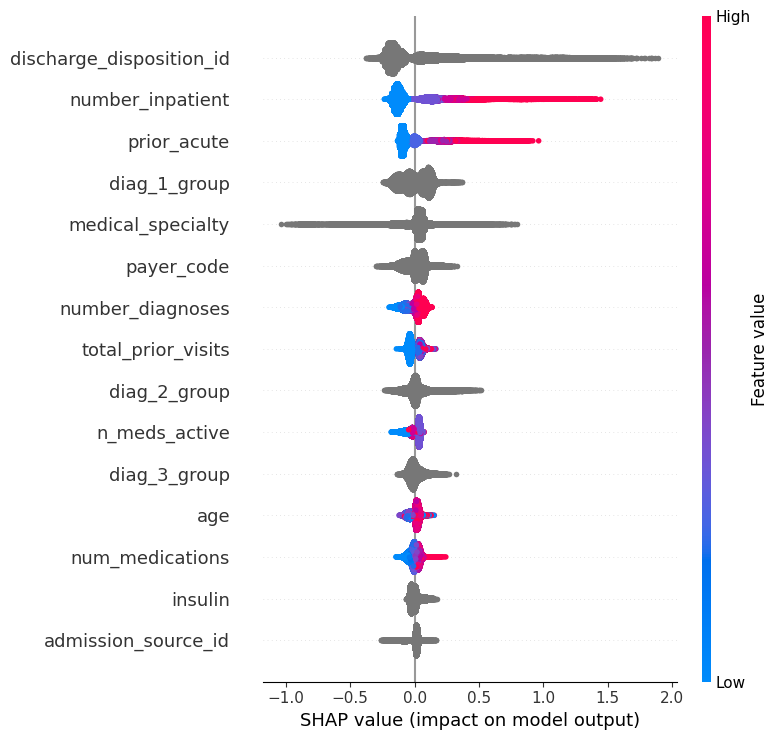

In [11]:
shap.summary_plot(sv_pos, X_cat, max_display=15)

## 6. Risk stratification

Descriptive rates behind the model's top features and decile analysis on
out-of-fold predictions.

In [12]:
d = df.copy()
d["pred_oof"] = oof_lgb

print("readmission rate by prior inpatient visits:")
print(d.groupby(d.number_inpatient.clip(upper=4))[TARGET].agg(["mean", "size"]).round(4))

print("\nreadmission rate by discharge destination:")
print(d.groupby("discharge_group")[TARGET].agg(["mean", "size"])
        .sort_values("mean", ascending=False).round(4))

d["decile"] = pd.qcut(d.pred_oof, 10, labels=False, duplicates="drop")
print("\nout-of-fold risk deciles:")
print(d.groupby("decile")[TARGET].agg(["mean", "size"]).round(4))

readmission rate by prior inpatient visits:
                    mean   size
number_inpatient               
0                 0.0859  66245
1                 0.1325  18984
2                 0.1793   7300
3                 0.2103   3271
4                 0.3136   3543

readmission rate by discharge destination:
                   mean   size
discharge_group               
Rehab            0.2770   1993
Other            0.2000     55
Facility         0.1898   3519
SNF              0.1466  14002
AMA              0.1445    623
HomeIV           0.1389    108
ICF              0.1276    815
HomeHealth       0.1270  12902
Unknown          0.1177   4680
Home             0.0930  60234
LongTerm         0.0728    412

out-of-fold risk deciles:
          mean  size
decile              
0       0.0370  9935
1       0.0574  9934
2       0.0636  9934
3       0.0726  9934
4       0.0898  9935
5       0.1062  9934
6       0.1178  9934
7       0.1370  9934
8       0.1721  9934
9       0.2854  9935


## 7. Calibration

Whether predicted probabilities mean what they claim. No resampling or class
weighting was used, since both distort probabilities.

   predicted  observed
0     0.0415    0.0370
1     0.0556    0.0574
2     0.0658    0.0636
3     0.0761    0.0726
4     0.0879    0.0898
5     0.1018    0.1062
6     0.1182    0.1178
7     0.1398    0.1370
8     0.1736    0.1721
9     0.2751    0.2854


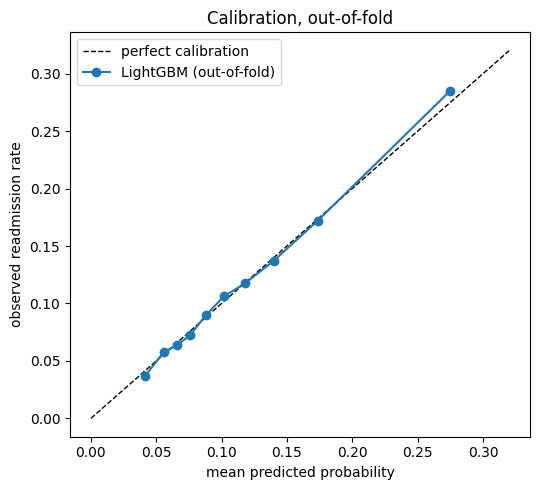

In [13]:
prob_true, prob_pred = calibration_curve(y, oof_lgb, n_bins=10, strategy="quantile")
print(pd.DataFrame({"predicted": prob_pred, "observed": prob_true}).round(4))

fig, ax = plt.subplots(figsize=(5.5, 5))
ax.plot([0, 0.32], [0, 0.32], "k--", lw=1, label="perfect calibration")
ax.plot(prob_pred, prob_true, "o-", label="LightGBM (out-of-fold)")
ax.set_xlabel("mean predicted probability")
ax.set_ylabel("observed readmission rate")
ax.set_title("Calibration, out-of-fold")
ax.legend()
plt.tight_layout()
plt.show()

## 8. Fairness audit

Discrimination and calibration broken out by race, sex, and age band.
`calib_gap` is mean predicted minus observed: negative means the group is
systematically under-scored.

In [14]:
def subgroup_report(d, col, y_col=TARGET, score_col="pred_oof", min_n=200):
    rows = []
    for name, g in d.groupby(col, observed=True):
        if len(g) < min_n or g[y_col].nunique() < 2:
            continue
        rows.append({
            col: name,
            "n": len(g),
            "prevalence": g[y_col].mean(),
            "auroc": roc_auc_score(g[y_col], g[score_col]),
            "auprc": average_precision_score(g[y_col], g[score_col]),
            "mean_pred": g[score_col].mean(),
            "calib_gap": g[score_col].mean() - g[y_col].mean(),
        })
    return pd.DataFrame(rows).sort_values("n", ascending=False).round(4)


d["age_band"] = pd.cut(d.age, [0, 40, 60, 75, 100],
                       labels=["<40", "40-60", "60-75", "75+"])

for col in ["race", "gender", "age_band"]:
    print(f"\n=== {col} ===")
    print(subgroup_report(d, col).to_string(index=False))


=== race ===
           race     n  prevalence  auroc  auprc  mean_pred  calib_gap
      Caucasian 74220      0.1153 0.6794 0.2409     0.1144    -0.0009
AfricanAmerican 18772      0.1145 0.6712 0.2245     0.1152     0.0007
        Missing  2234      0.0842 0.6509 0.1597     0.0893     0.0051
       Hispanic  2017      0.1051 0.7434 0.2909     0.1055     0.0004
          Other  1472      0.0978 0.6834 0.2192     0.1024     0.0046
          Asian   628      0.1035 0.7314 0.3159     0.0995    -0.0040

=== gender ===
gender     n  prevalence  auroc  auprc  mean_pred  calib_gap
Female 53454      0.1146 0.6820 0.2388     0.1153     0.0007
  Male 45886      0.1130 0.6764 0.2348     0.1114    -0.0016

=== age_band ===
age_band     n  prevalence  auroc  auprc  mean_pred  calib_gap
   60-75 47390      0.1171 0.6683 0.2308     0.1155    -0.0015
   40-60 26667      0.1009 0.7035 0.2441     0.1035     0.0026
     75+ 19023      0.1247 0.6283 0.2132     0.1242    -0.0005
     <40  6263      0.1122 

## 9. Saved figures for the README

In [15]:
FIG = Path.cwd().parent / "reports" / "figures"
FIG.mkdir(parents=True, exist_ok=True)

# SHAP summary
shap.summary_plot(sv_pos, X_cat, max_display=15, show=False)
plt.tight_layout()
plt.savefig(FIG / "shap_summary.png", dpi=150, bbox_inches="tight")
plt.close()

# Calibration
fig, ax = plt.subplots(figsize=(5.5, 5))
ax.plot([0, 0.32], [0, 0.32], "k--", lw=1, label="perfect calibration")
ax.plot(prob_pred, prob_true, "o-", color="#1f77b4", label="LightGBM (out-of-fold)")
ax.set_xlabel("mean predicted probability")
ax.set_ylabel("observed readmission rate")
ax.set_title("Calibration, out-of-fold")
ax.legend()
plt.tight_layout()
plt.savefig(FIG / "calibration.png", dpi=150)
plt.close()

# Decile lift
dec = d.groupby("decile")[TARGET].mean()
fig, ax = plt.subplots(figsize=(7, 4.5))
ax.bar(dec.index, dec.values, color="#4c72b0")
ax.axhline(y.mean(), color="crimson", ls="--", lw=1.5, label=f"base rate ({y.mean():.1%})")
ax.set_xlabel("risk decile (out-of-fold)")
ax.set_ylabel("observed 30-day readmission rate")
ax.set_title("Readmission rate by predicted risk decile")
ax.set_xticks(range(10))
ax.legend()
plt.tight_layout()
plt.savefig(FIG / "decile_lift.png", dpi=150)
plt.close()

# AUROC by age band
ab = subgroup_report(d, "age_band")
overall = evaluate(y, oof_lgb)["auroc"]
fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(ab["age_band"].astype(str), ab["auroc"], color="#55a868")
ax.axhline(overall, color="crimson", ls="--", lw=1.5, label=f"overall ({overall:.3f})")
ax.set_ylim(0.55, 0.80)
ax.set_ylabel("AUROC")
ax.set_xlabel("age band")
ax.set_title("Discrimination by age band")
ax.legend()
plt.tight_layout()
plt.savefig(FIG / "auroc_by_age.png", dpi=150)
plt.close()

print(sorted(p.name for p in FIG.glob("*.png")))

['auroc_by_age.png', 'calibration.png', 'decile_lift.png', 'shap_summary.png']
